# 🔴 FRAUD DETECTION — ПОЛНЫЙ ПАЙПЛАЙН
### Флаги → Риск-скоринг → ML модели → Итоговый отчёт
---

In [1]:
# ════════════════════════════════════════════════════════════════
# 📦 БЛОК 1 — УСТАНОВКА И ИМПОРТЫ
# ════════════════════════════════════════════════════════════════
!pip install pyod imbalanced-learn xgboost lightgbm --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML модели
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from pyod.models.iforest import IForest

print('✅ Все библиотеки загружены')

✅ Все библиотеки загружены


In [2]:
# ════════════════════════════════════════════════════════════════
# 🎨 БЛОК 2 — НАСТРОЙКА СТИЛЯ
# ════════════════════════════════════════════════════════════════
DARK_BG    = '#0f1117'
DARK_AX    = '#161b22'
DARK_EDGE  = '#30363d'
TEXT_MAIN  = '#f0f6fc'
TEXT_SUB   = '#c9d1d9'
TEXT_MUTED = '#8b949e'

RISK_COLORS = {
    'Критический': '#ff4444',
    'Высокий':     '#ff8c00',
    'Средний':     '#ffd700',
    'Низкий':      '#3fb950',
}

FLAG_COLORS = [
    '#ff4444', '#ff8c00', '#ffd700',
    '#58a6ff', '#bc8cff', '#3fb950',
    '#f78166', '#79c0ff', '#56d364'
]

plt.rcParams.update({
    'figure.facecolor':  DARK_BG,
    'axes.facecolor':    DARK_AX,
    'axes.edgecolor':    DARK_EDGE,
    'axes.labelcolor':   TEXT_SUB,
    'xtick.color':       TEXT_MUTED,
    'ytick.color':       TEXT_MUTED,
    'text.color':        TEXT_SUB,
    'grid.color':        '#21262d',
    'grid.linewidth':    0.8,
    'font.family':       'monospace',
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlecolor':   TEXT_MAIN,
    'legend.facecolor':  DARK_AX,
    'legend.edgecolor':  DARK_EDGE,
})

print('✅ Стиль настроен')

✅ Стиль настроен


In [3]:
# ════════════════════════════════════════════════════════════════
# 📂 БЛОК 3 — ЗАГРУЗКА И ПРЕДОБРАБОТКА ДАННЫХ
# ════════════════════════════════════════════════════════════════
PATH = r'C:\Users\derbe\Downloads\archive (1)\transactions_data.csv'

df = pd.read_csv(PATH)

# Чистим и типизируем
df['amount'] = df['amount'].str.replace('$', '', regex=False).astype(float)
df['date']   = pd.to_datetime(df['date'])
df['hour']   = df['date'].dt.hour
df['month']  = df['date'].dt.month
df['day']    = df['date'].dt.day
df['weekday']= df['date'].dt.dayofweek   # 0=Пн, 6=Вс
df['is_weekend'] = (df['weekday'] >= 5).astype(int)
df['is_online']  = (df['merchant_city'] == 'ONLINE').astype(int)
df['has_error']  = df['errors'].notna().astype(int)

# Глобальные метрики
AVG_TOTAL  = df['amount'].mean()
MED_TOTAL  = df['amount'].median()
STD_TOTAL  = df['amount'].std()

print(f'✅ Данные загружены: {df.shape[0]:,} строк, {df.shape[1]} колонок')
print(f'   Средний чек:  ${AVG_TOTAL:.2f}')
print(f'   Медиана:      ${MED_TOTAL:.2f}')
print(f'   Период:       {df["date"].min().date()} → {df["date"].max().date()}')
df.head(3)

✅ Данные загружены: 13,305,915 строк, 19 колонок
   Средний чек:  $42.98
   Медиана:      $28.99
   Период:       2010-01-01 → 2019-10-31


,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,hour,month,day,weekday,is_weekend,is_online,has_error
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN,0,1,1,4,0,0,0
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN,0,1,1,4,0,0,0
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN,0,1,1,4,0,0,0


In [4]:
# ════════════════════════════════════════════════════════════════
# 🚩 БЛОК 4 — ФЛАГИ ФРОДА (9 штук)
# ════════════════════════════════════════════════════════════════

# ── Вспомогательные агрегаты ─────────────────────────────────
client_avg = df.groupby('client_id')['amount'].mean().rename('client_avg_amount')
client_std = df.groupby('client_id')['amount'].std().fillna(0).rename('client_std_amount')
df = df.join(client_avg, on='client_id').join(client_std, on='client_id')

# ────────────────────────────────────────────────────────────────
# 🚩 ФЛАГ 1 — VELOCITY: много транзакций в день, разные штаты
# Признак: клиент делает >3 транзакции в день,
# средний чек выше обычного на 34%+, в 2+ штатах
# ────────────────────────────────────────────────────────────────
df_city  = df[(df['merchant_city'] != 'ONLINE') & df['merchant_state'].notna()]
daily    = df_city.groupby(['client_id', 'day']).agg(
    count_trans = ('amount', 'count'),
    avg_per_day = ('amount', 'mean'),
    unique_states = ('merchant_state', 'nunique')
).reset_index()
daily = daily.merge(client_avg.reset_index(), on='client_id')
velocity_clients = daily[
    (daily['avg_per_day']   > daily['client_avg_amount'] * 1.34) &
    (daily['unique_states'] > 1) &
    (daily['count_trans']   > 3)
][['client_id']].drop_duplicates()
print(f'🚩 Flag 1 VELOCITY:    {len(velocity_clients):>5} клиентов')

# ────────────────────────────────────────────────────────────────
# 🚩 ФЛАГ 2 — BAD MERCH: мерчанты с высоким % ошибок
# Признак: >40% транзакций у мерчанта с ошибкой
# ────────────────────────────────────────────────────────────────
merch_stats = df.groupby('merchant_id').agg(
    error_count  = ('errors', 'count'),
    total_count  = ('id', 'count'),
    avg_amount   = ('amount', 'mean'),
    state        = ('merchant_state', 'first')
)
merch_stats['error_pct'] = merch_stats['error_count'] / merch_stats['total_count'] * 100
bad_merch = merch_stats[merch_stats['error_pct'] > 40]
bad_merch_clients = df[df['merchant_id'].isin(bad_merch.index)][['client_id']].drop_duplicates()
print(f'🚩 Flag 2 BAD_MERCH:   {len(bad_merch_clients):>5} клиентов ({len(bad_merch)} мерчантов)')

# ────────────────────────────────────────────────────────────────
# 🚩 ФЛАГ 3 — NIGHT TX: ночные транзакции в 3х выше дневных
# Признак: средний чек 00:00-05:00 > дневного в 3 раза
# ────────────────────────────────────────────────────────────────
night_avg = df[df['hour'].between(0, 5)].groupby('client_id')['amount'].mean()
day_avg   = df[df['hour'].between(6, 23)].groupby('client_id')['amount'].mean()
night_df  = pd.DataFrame({'night_avg': night_avg, 'day_avg': day_avg}).dropna()
night_clients = night_df[night_df['night_avg'] > night_df['day_avg'] * 3][[]].reset_index()[['client_id']]
print(f'🚩 Flag 3 NIGHT_TX:    {len(night_clients):>5} клиентов')

# ────────────────────────────────────────────────────────────────
# 🚩 ФЛАГ 4 — FAST TX: две крупные транзакции < 4 минут
# Признак: следующая транзакция через <4 мин, обе >5x avg
# ────────────────────────────────────────────────────────────────
fast = df.sort_values(['client_id', 'date']).copy()
fast['next_date']    = fast.groupby('client_id')['date'].shift(-1)
fast['next_amount']  = fast.groupby('client_id')['amount'].shift(-1)
fast['diff_minutes'] = (fast['next_date'] - fast['date']).dt.total_seconds() / 60
fast_clients = fast[
    (fast['diff_minutes'] > 0) &
    (fast['diff_minutes'] < 4) &
    (fast['amount']       > AVG_TOTAL * 5) &
    (fast['next_amount']  > AVG_TOTAL * 5)
][['client_id']].drop_duplicates()
print(f'🚩 Flag 4 FAST_TX:     {len(fast_clients):>5} клиентов')

# ────────────────────────────────────────────────────────────────
# 🚩 ФЛАГ 5 — ONLINE SPIKE: онлайн транзакции резко выросли
# Признак: клиент тратит онлайн в 2x больше обычного
# ────────────────────────────────────────────────────────────────
online_avg = df[df['is_online'] == 1].groupby('client_id')['amount'].mean()
offline_avg = df[df['is_online'] == 0].groupby('client_id')['amount'].mean()
online_df   = pd.DataFrame({'online': online_avg, 'offline': offline_avg}).dropna()
online_clients = online_df[online_df['online'] > online_df['offline'] * 2][[]].reset_index()[['client_id']]
print(f'🚩 Flag 5 ONLINE_SPIKE:{len(online_clients):>5} клиентов')

# ────────────────────────────────────────────────────────────────
# 🚩 ФЛАГ 6 — WEEKEND BINGE: аномальные траты в выходные
# Признак: в выходные тратит в 2.5x больше чем в будни
# ────────────────────────────────────────────────────────────────
weekend_avg = df[df['is_weekend'] == 1].groupby('client_id')['amount'].mean()
weekday_avg = df[df['is_weekend'] == 0].groupby('client_id')['amount'].mean()
weekend_df  = pd.DataFrame({'weekend': weekend_avg, 'weekday': weekday_avg}).dropna()
weekend_clients = weekend_df[weekend_df['weekend'] > weekend_df['weekday'] * 2.5][[]].reset_index()[['client_id']]
print(f'🚩 Flag 6 WEEKEND:     {len(weekend_clients):>5} клиентов')

# ────────────────────────────────────────────────────────────────
# 🚩 ФЛАГ 7 — HIGH UNIQUE MERCH: слишком много разных мерчантов
# Признак: клиент посещает >95 перцентиля уникальных мерчантов
# ────────────────────────────────────────────────────────────────
merch_count   = df.groupby('client_id')['merchant_id'].nunique()
merch_thresh  = merch_count.quantile(0.95)
high_merch_clients = merch_count[merch_count > merch_thresh].reset_index()[['client_id']]
print(f'🚩 Flag 7 HIGH_MERCH:  {len(high_merch_clients):>5} клиентов (порог: {merch_thresh:.0f} мерчантов)')

# ────────────────────────────────────────────────────────────────
# 🚩 ФЛАГ 8 — AMOUNT SPIKE: одна транзакция в 10x выше обычной
# Признак: есть хотя бы одна транзакция >10x личного среднего
# ────────────────────────────────────────────────────────────────
spike = df[df['amount'] > df['client_avg_amount'] * 10]
spike_clients = spike[['client_id']].drop_duplicates()
print(f'🚩 Flag 8 AMOUNT_SPIKE:{len(spike_clients):>5} клиентов')

# ────────────────────────────────────────────────────────────────
# 🚩 ФЛАГ 9 — CROSS STATE: транзакции в 4+ штатах за месяц
# Признак: в один месяц транзакции в разных штатах
# ────────────────────────────────────────────────────────────────
state_month = df[df['merchant_state'].notna()].groupby(
    ['client_id', 'month'])['merchant_state'].nunique()
cross_state_clients = state_month[state_month >= 4].reset_index()[['client_id']].drop_duplicates()
print(f'🚩 Flag 9 CROSS_STATE: {len(cross_state_clients):>5} клиентов')

🚩 Flag 1 VELOCITY:      141 клиентов
🚩 Flag 2 BAD_MERCH:     339 клиентов (397 мерчантов)
🚩 Flag 3 NIGHT_TX:      135 клиентов
🚩 Flag 4 FAST_TX:       309 клиентов
🚩 Flag 5 ONLINE_SPIKE:  585 клиентов
🚩 Flag 6 WEEKEND:         0 клиентов
🚩 Flag 7 HIGH_MERCH:     61 клиентов (порог: 470 мерчантов)
🚩 Flag 8 AMOUNT_SPIKE: 1209 клиентов
🚩 Flag 9 CROSS_STATE:  1210 клиентов


In [5]:
# ════════════════════════════════════════════════════════════════
# 📊 БЛОК 5 — СБОРКА RISK SCORE
# ════════════════════════════════════════════════════════════════
clients = df[['client_id']].drop_duplicates().reset_index(drop=True)

# Все флаги в одном словаре
flags = {
    'flag_velocity':    velocity_clients,
    'flag_bad_merch':   bad_merch_clients,
    'flag_night':       night_clients,
    'flag_fast_tx':     fast_clients,
    'flag_online':      online_clients,
    'flag_weekend':     weekend_clients,
    'flag_high_merch':  high_merch_clients,
    'flag_spike':       spike_clients,
    'flag_cross_state': cross_state_clients,
}

for flag_name, flag_df in flags.items():
    clients = clients.merge(flag_df.assign(**{flag_name: 1}),
                            on='client_id', how='left')
    clients[flag_name] = clients[flag_name].fillna(0).astype(int)

# Risk Score = сумма всех флагов
flag_cols = list(flags.keys())
clients['risk_score'] = clients[flag_cols].sum(axis=1)

# Risk Level
clients['risk_level'] = np.select(
    [
        clients['risk_score'] >= 5,
        clients['risk_score'].between(3, 4),
        clients['risk_score'].between(1, 2),
    ],
    ['Критический', 'Высокий', 'Средний'],
    default='Низкий'
)

print('✅ Risk Score собран:')
print(clients['risk_level'].value_counts().to_string())
print(f'\nВсего клиентов с флагами: {clients["risk_score"].gt(0).sum():,}')

✅ Risk Score собран:
risk_level
Высокий        818
Средний        273
Критический    128

Всего клиентов с флагами: 1,219


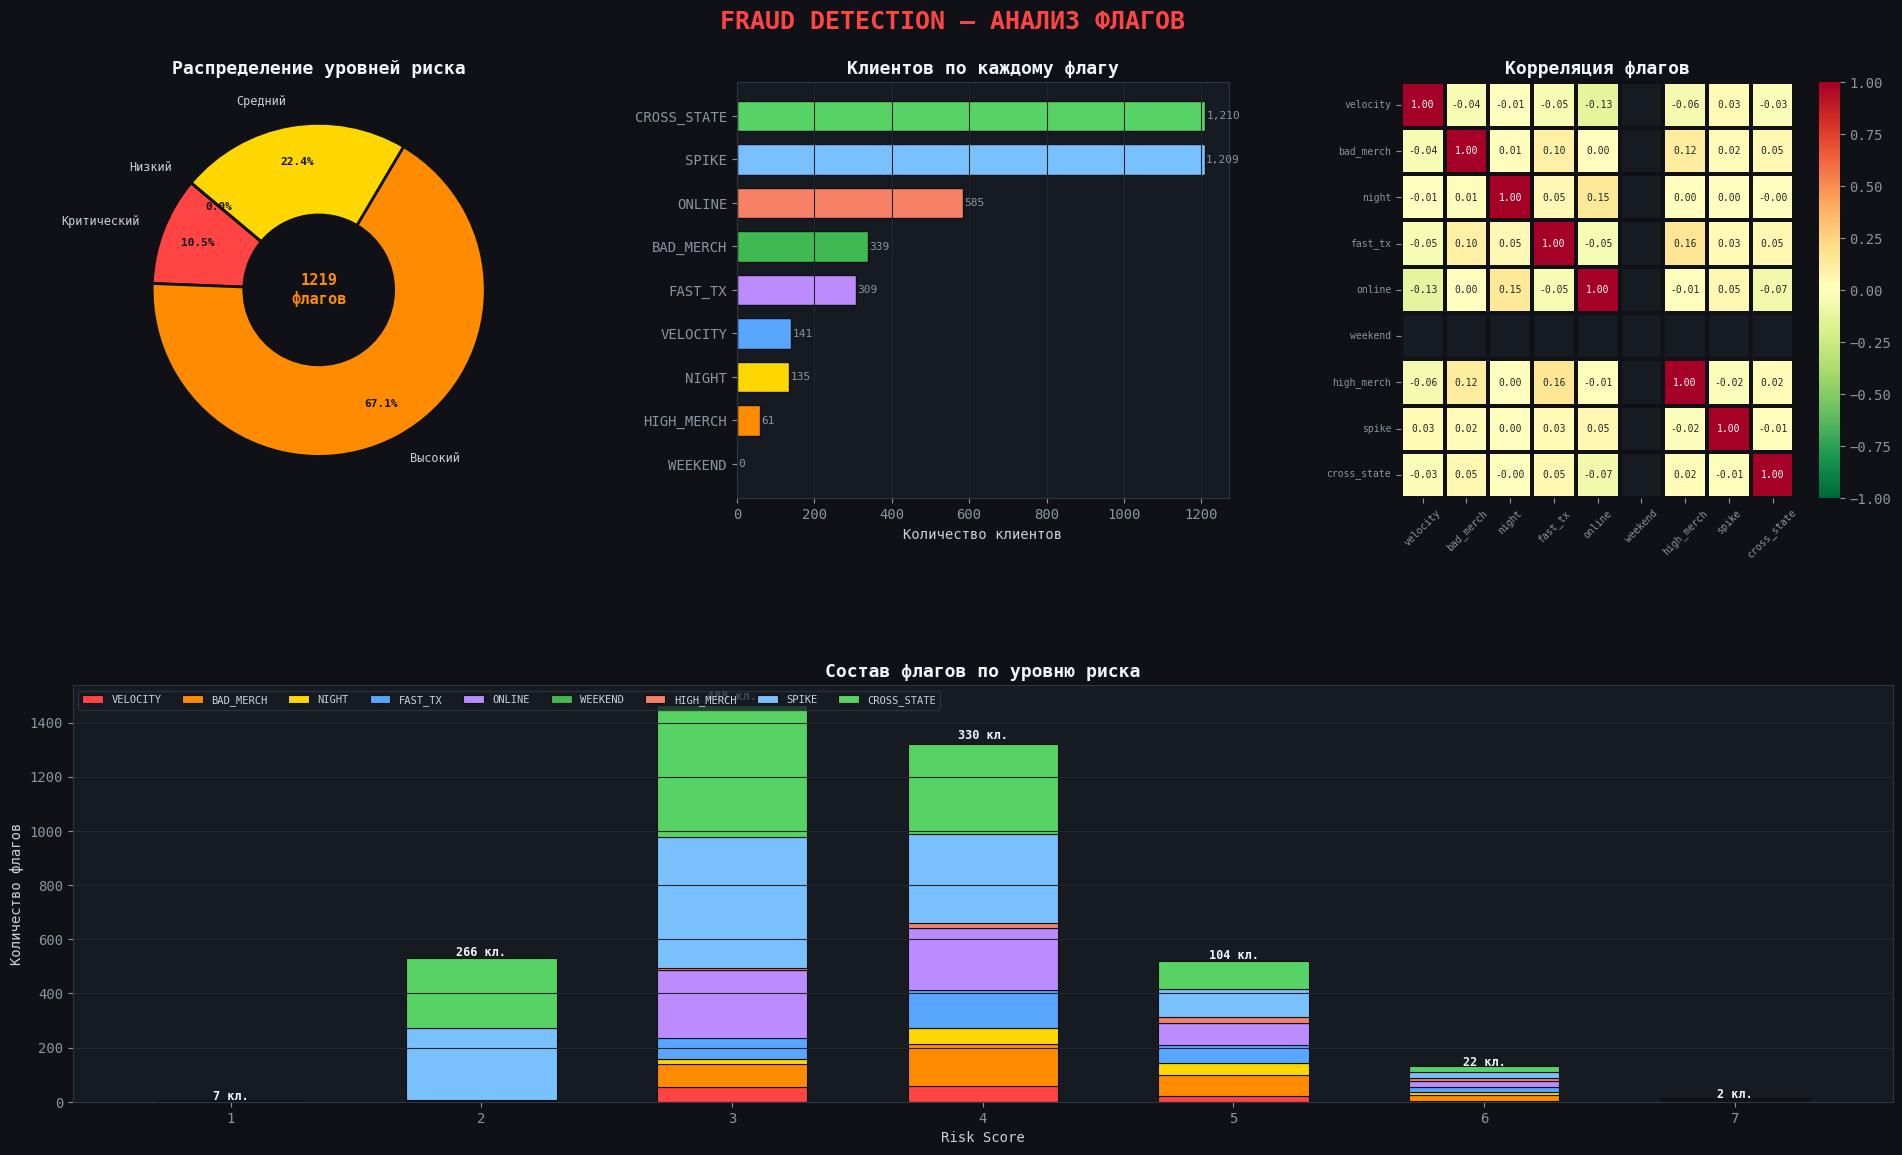

In [6]:
# ════════════════════════════════════════════════════════════════
# 📈 БЛОК 6 — ВИЗУАЛИЗАЦИЯ ФЛАГОВ И РИСКА
# ════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 12), facecolor=DARK_BG)
fig.suptitle('FRAUD DETECTION — АНАЛИЗ ФЛАГОВ', fontsize=18,
             fontweight='bold', color='#ff4444', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35,
                       left=0.06, right=0.97, top=0.92, bottom=0.07)

# ── График 1: Donut риска ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
order  = ['Критический', 'Высокий', 'Средний', 'Низкий']
rc     = clients['risk_level'].value_counts()
sizes  = [rc.get(r, 0) for r in order]
colors = [RISK_COLORS[r] for r in order]
wedges, texts, autotexts = ax1.pie(
    sizes, labels=order, colors=colors, autopct='%1.1f%%',
    startangle=140, pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor=DARK_BG, linewidth=2),
    labeldistance=1.15
)
for at in autotexts: at.set_fontsize(8); at.set_color(DARK_BG); at.set_fontweight('bold')
for t in texts:      t.set_fontsize(8.5); t.set_color(TEXT_SUB)
ax1.text(0, 0, f"{clients['risk_score'].gt(0).sum()}\nфлагов",
         ha='center', va='center', fontsize=11, color='#ff8c00', fontweight='bold')
ax1.set_title('Распределение уровней риска')

# ── График 2: Флаги по количеству клиентов ────────────────────
ax2 = fig.add_subplot(gs[0, 1])
flag_counts = {f.replace('flag_', '').upper(): clients[f].sum() for f in flag_cols}
flag_df_plot = pd.Series(flag_counts).sort_values()
bars = ax2.barh(flag_df_plot.index, flag_df_plot.values,
                color=FLAG_COLORS[:len(flag_df_plot)], edgecolor=DARK_BG, height=0.7)
for bar, val in zip(bars, flag_df_plot.values):
    ax2.text(val + 3, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=8, color=TEXT_MUTED)
ax2.set_title('Клиентов по каждому флагу')
ax2.set_xlabel('Количество клиентов')
ax2.grid(True, axis='x')

# ── График 3: Корреляция флагов ───────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
corr = clients[flag_cols].corr()
short_names = [f.replace('flag_', '') for f in flag_cols]
sns.heatmap(corr, ax=ax3, annot=True, fmt='.2f', cmap='RdYlGn_r',
            xticklabels=short_names, yticklabels=short_names,
            linewidths=1.5, linecolor=DARK_BG,
            annot_kws={'size': 7}, vmin=-1, vmax=1)
ax3.set_title('Корреляция флагов')
ax3.tick_params(axis='x', rotation=45, labelsize=7)
ax3.tick_params(axis='y', rotation=0, labelsize=7)

# ── График 4: Risk Score распределение (stacked bar) ──────────
ax4 = fig.add_subplot(gs[1, :])
score_flag = clients.groupby('risk_score')[flag_cols].sum()
bottom = np.zeros(len(score_flag))
x = score_flag.index.astype(str)
for i, (col, color) in enumerate(zip(flag_cols, FLAG_COLORS)):
    label = col.replace('flag_', '').upper()
    ax4.bar(x, score_flag[col], bottom=bottom, label=label,
            color=color, edgecolor=DARK_BG, linewidth=0.8, width=0.6)
    bottom += score_flag[col].values

client_counts = clients['risk_score'].value_counts().sort_index()
for i, (score, count) in enumerate(client_counts.items()):
    total_h = score_flag.loc[score].sum() if score in score_flag.index else 0
    ax4.text(i, total_h + total_h * 0.015, f'{count} кл.',
             ha='center', fontsize=8.5, color=TEXT_MAIN, fontweight='bold')

ax4.set_xlabel('Risk Score'); ax4.set_ylabel('Количество флагов')
ax4.set_title('Состав флагов по уровню риска')
ax4.legend(fontsize=7.5, ncol=9, loc='upper left')
ax4.grid(True, axis='y')

plt.show()

In [7]:
# ════════════════════════════════════════════════════════════════
# 🤖 БЛОК 7 — ПОДГОТОВКА ДАННЫХ ДЛЯ ML
# ════════════════════════════════════════════════════════════════

# Сырые фичи по клиенту
client_features = df.groupby('client_id').agg(
    total_tx        = ('amount', 'count'),
    avg_amount      = ('amount', 'mean'),
    max_amount      = ('amount', 'max'),
    min_amount      = ('amount', 'min'),
    std_amount      = ('amount', 'std'),
    median_amount   = ('amount', 'median'),
    avg_hour        = ('hour', 'mean'),
    night_ratio     = ('hour', lambda x: x.between(0, 5).mean()),
    weekend_ratio   = ('is_weekend', 'mean'),
    online_ratio    = ('is_online', 'mean'),
    unique_states   = ('merchant_state', 'nunique'),
    unique_merch    = ('merchant_id', 'nunique'),
    error_ratio     = ('has_error', 'mean'),
    unique_months   = ('month', 'nunique'),
).reset_index()

client_features['std_amount']    = client_features['std_amount'].fillna(0)
client_features['amount_range']  = client_features['max_amount'] - client_features['min_amount']
client_features['merch_per_tx']  = client_features['unique_merch'] / client_features['total_tx']
client_features['state_per_tx']  = client_features['unique_states'] / client_features['total_tx']

# Метка — Высокий и Критический риск
ml_df = client_features.merge(
    clients[['client_id', 'risk_score', 'risk_level']], on='client_id', how='left'
)
ml_df['is_fraud'] = (ml_df['risk_score'] >= 3).astype(int)

FEATURE_COLS = [
    'total_tx', 'avg_amount', 'max_amount', 'min_amount', 'std_amount',
    'median_amount', 'avg_hour', 'night_ratio', 'weekend_ratio', 'online_ratio',
    'unique_states', 'unique_merch', 'error_ratio', 'unique_months',
    'amount_range', 'merch_per_tx', 'state_per_tx'
]

X = ml_df[FEATURE_COLS]
y = ml_df['is_fraud']

# Масштабируем
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# SMOTE для балансировки
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
smote = SMOTE(random_state=42, k_neighbors=min(3, y_train.sum()-1))
X_train, y_train_sm = smote.fit_resample(X_train_raw, y_train)

print(f'✅ Данные готовы:')
print(f'   Train: {len(X_train):,}  (после SMOTE, фрод: {y_train_sm.sum():,})')
print(f'   Test:  {len(X_test_raw):,}  (фрод: {y_test.sum():,})')
print(f'   Фич:   {len(FEATURE_COLS)}')

✅ Данные готовы:
   Train: 1,514  (после SMOTE, фрод: 757)
   Test:  244  (фрод: 189)
   Фич:   17


In [8]:
# ════════════════════════════════════════════════════════════════
# 🤖 БЛОК 8 — ОБУЧЕНИЕ 5 МОДЕЛЕЙ
# ════════════════════════════════════════════════════════════════

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=6,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        scale_pos_weight=10, random_state=42,
        eval_metric='logloss', verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        class_weight='balanced', random_state=42, verbose=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.05,
        random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000,
        random_state=42, C=0.1
    ),
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train_sm)
    y_pred  = model.predict(X_test_raw)
    y_proba = model.predict_proba(X_test_raw)[:, 1]
    
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    auc    = roc_auc_score(y_test, y_proba)
    cm     = confusion_matrix(y_test, y_pred)
    
    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'y_proba':   y_proba,
        'report':    report,
        'auc':       auc,
        'cm':        cm,
        'precision': report.get('1', {}).get('precision', 0),
        'recall':    report.get('1', {}).get('recall', 0),
        'f1':        report.get('1', {}).get('f1-score', 0),
    }
    print(f'✅ {name:25} | AUC: {auc:.3f} | '
          f'Recall: {results[name]["recall"]:.3f} | '
          f'F1: {results[name]["f1"]:.3f}')

✅ Random Forest             | AUC: 0.717 | Recall: 0.735 | F1: 0.785
✅ XGBoost                   | AUC: 0.736 | Recall: 0.963 | F1: 0.886
✅ LightGBM                  | AUC: 0.722 | Recall: 0.862 | F1: 0.851
✅ Gradient Boosting         | AUC: 0.708 | Recall: 0.815 | F1: 0.826
✅ Logistic Regression       | AUC: 0.739 | Recall: 0.672 | F1: 0.760


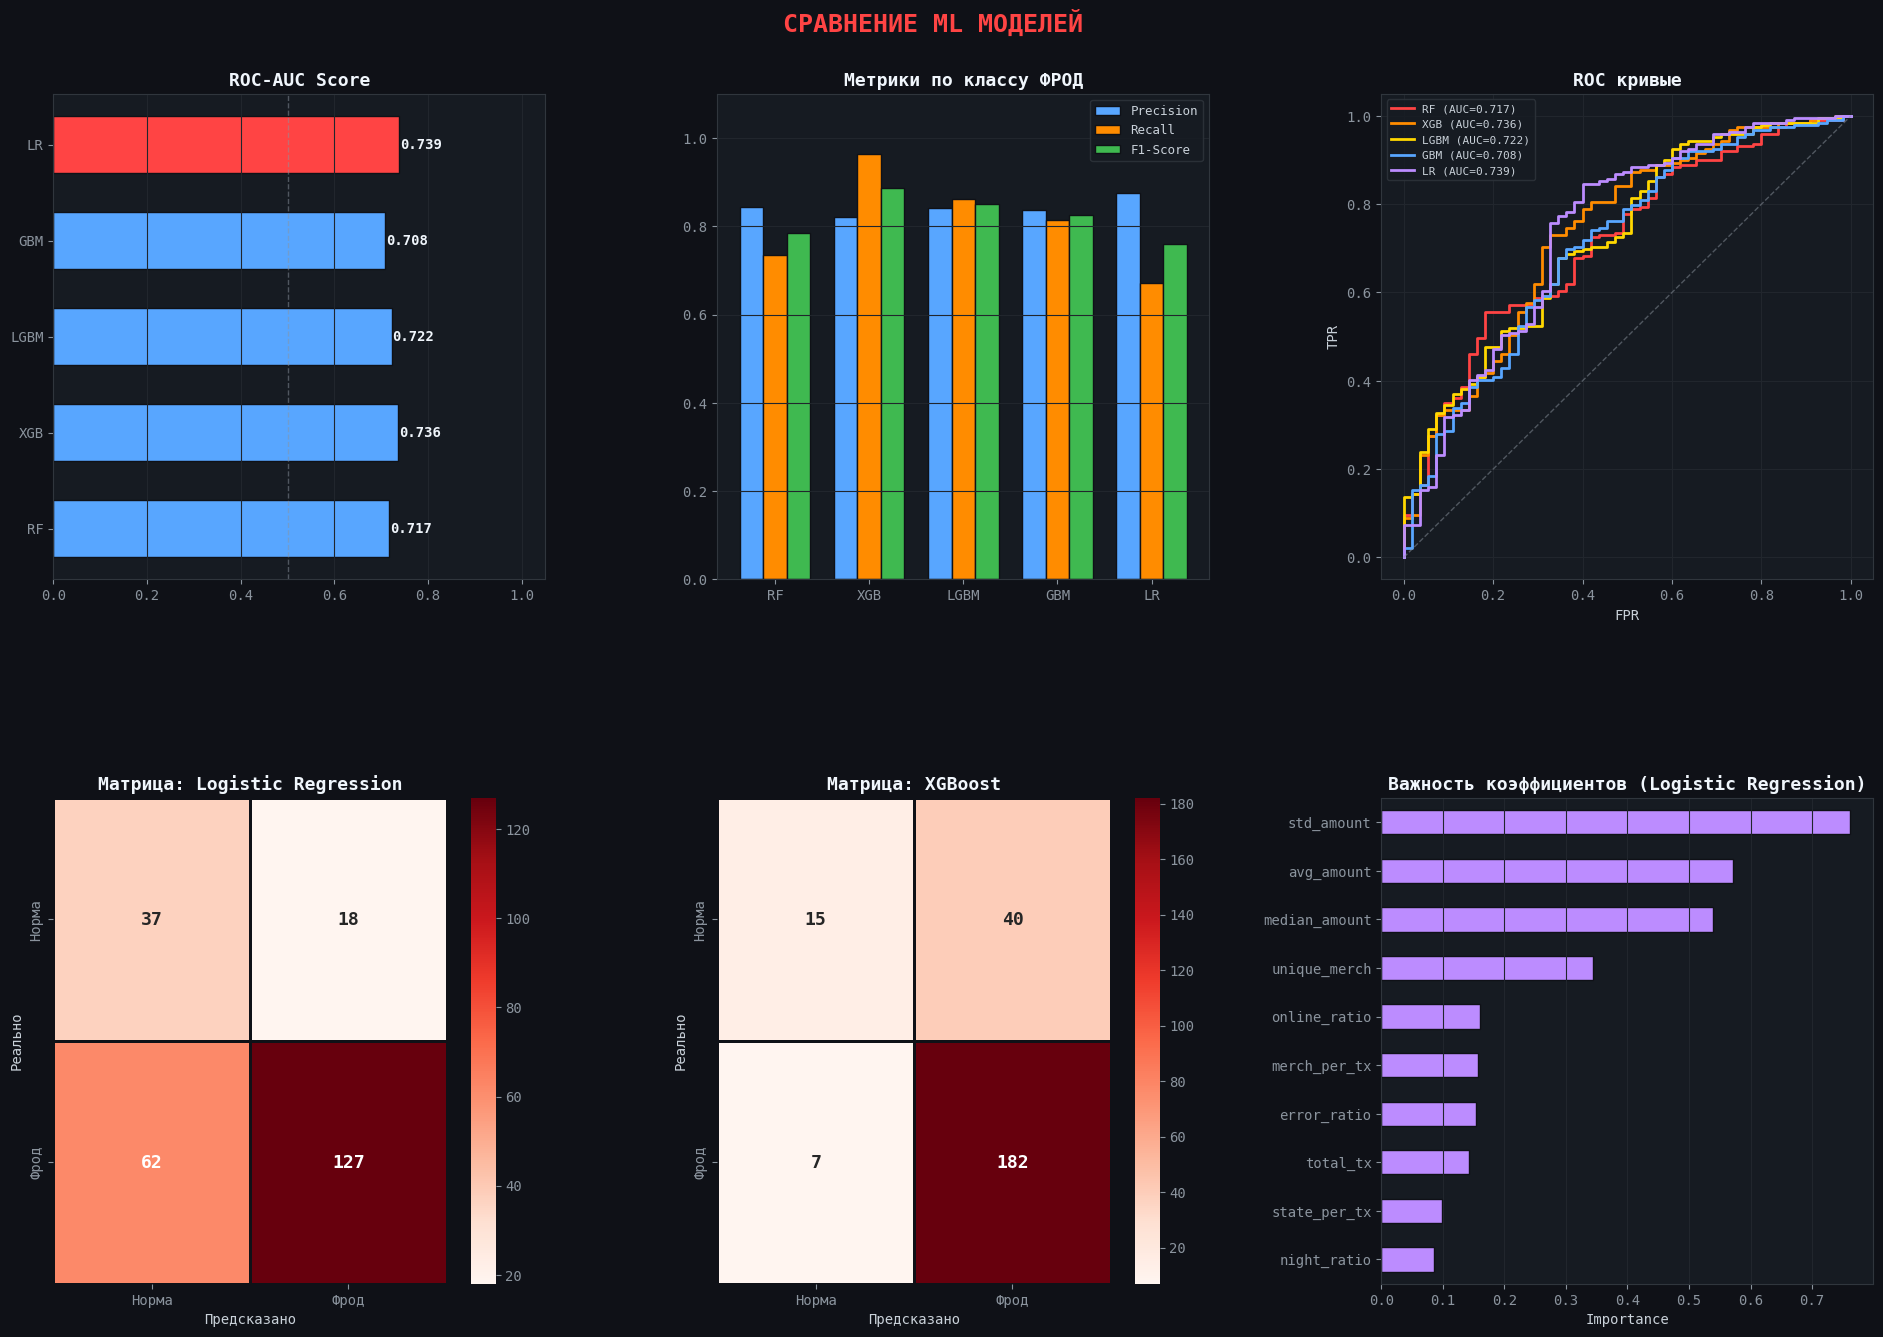


🏆 Лучшая модель: Logistic Regression (AUC=0.739)


In [21]:
# ════════════════════════════════════════════════════════════════
# 📊 БЛОК 9 — СРАВНЕНИЕ МОДЕЛЕЙ
# ════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 14), facecolor=DARK_BG)
fig.suptitle('СРАВНЕНИЕ ML МОДЕЛЕЙ', fontsize=18,
             fontweight='bold', color='#ff4444', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35,
                       left=0.06, right=0.97, top=0.92, bottom=0.07)

model_names = list(results.keys())
short_names = ['RF', 'XGB', 'LGBM', 'GBM', 'LR']

# ── График 1: AUC сравнение ───────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
aucs = [results[n]['auc'] for n in model_names]
bars = ax1.barh(short_names, aucs,
                color=['#ff4444' if a == max(aucs) else '#58a6ff' for a in aucs],
                edgecolor=DARK_BG, height=0.6)
for bar, val in zip(bars, aucs):
    ax1.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10, fontweight='bold', color=TEXT_MAIN)
ax1.set_title('ROC-AUC Score')
ax1.set_xlim(0, 1.05)
ax1.axvline(0.5, color=TEXT_MUTED, linestyle='--', linewidth=1, alpha=0.5)
ax1.grid(True, axis='x')

# ── График 2: Recall / Precision / F1 ────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
metrics_df = pd.DataFrame({
    'Precision': [results[n]['precision'] for n in model_names],
    'Recall':    [results[n]['recall']    for n in model_names],
    'F1-Score':  [results[n]['f1']        for n in model_names],
}, index=short_names)
x = np.arange(len(short_names))
w = 0.25
for i, (col, color) in enumerate(zip(metrics_df.columns, ['#58a6ff', '#ff8c00', '#3fb950'])):
    ax2.bar(x + i*w, metrics_df[col], width=w, label=col, color=color, edgecolor=DARK_BG)
ax2.set_title('Метрики по классу ФРОД')
ax2.set_xticks(x + w); ax2.set_xticklabels(short_names)
ax2.legend(fontsize=9); ax2.grid(True, axis='y')
ax2.set_ylim(0, 1.1)

# ── График 3: ROC кривые ──────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
roc_colors = ['#ff4444', '#ff8c00', '#ffd700', '#58a6ff', '#bc8cff']
for (name, res), color, short in zip(results.items(), roc_colors, short_names):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax3.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{short} (AUC={res["auc"]:.3f})')
ax3.plot([0,1],[0,1], '--', color=TEXT_MUTED, linewidth=1, alpha=0.5)
ax3.set_title('ROC кривые'); ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
ax3.legend(fontsize=8); ax3.grid(True)

# ── Графики 4-5: Матрицы лучших двух моделей ─────────────────
best_models = sorted(results.items(), key=lambda x: x[1]['auc'], reverse=True)[:2]
for i, (name, res) in enumerate(best_models):
    ax = fig.add_subplot(gs[1, i])
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='Reds', ax=ax,
                xticklabels=['Норма', 'Фрод'],
                yticklabels=['Норма', 'Фрод'],
                linewidths=2, linecolor=DARK_BG,
                annot_kws={'size': 13, 'weight': 'bold'})
    ax.set_title(f'Матрица: {name}')
    ax.set_xlabel('Предсказано'); ax.set_ylabel('Реально')

# ── График 6: Feature Importance лучшей модели ───────────────

ax6 = fig.add_subplot(gs[1, 2])
best_model = results[best_name]['model']

if hasattr(best_model, 'feature_importances_'):
    # RF, XGBoost, LightGBM, GBM
    imp = pd.Series(best_model.feature_importances_, index=FEATURE_COLS).sort_values()
    imp.tail(10).plot(kind='barh', ax=ax6, color='#58a6ff', edgecolor=DARK_BG)
    ax6.set_title(f'Топ-10 фич ({best_name})')

elif hasattr(best_model, 'coef_'):
    # Logistic Regression
    imp = pd.Series(np.abs(best_model.coef_[0]), index=FEATURE_COLS).sort_values()
    imp.tail(10).plot(kind='barh', ax=ax6, color='#bc8cff', edgecolor=DARK_BG)
    ax6.set_title(f'Важность коэффициентов ({best_name})')

ax6.set_xlabel('Importance'); ax6.grid(True, axis='x')

plt.show()
print(f'\n🏆 Лучшая модель: {best_name} (AUC={results[best_name]["auc"]:.3f})')

✅ Isolation Forest: найдено 2,000 аномалий (2.00%)


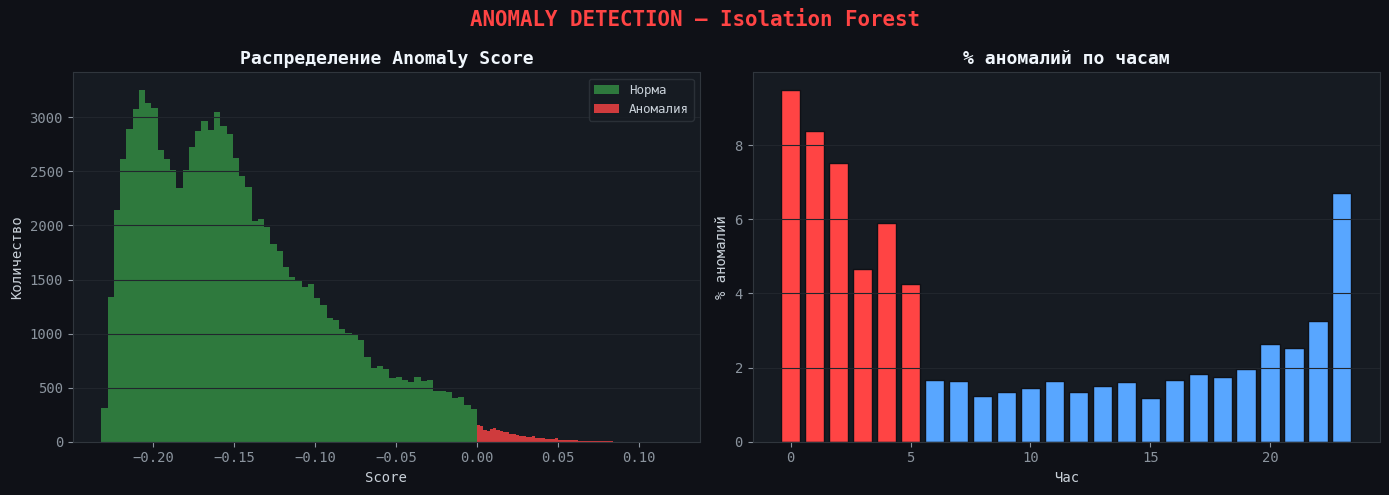

In [10]:
# ════════════════════════════════════════════════════════════════
# 🔍 БЛОК 10 — ANOMALY DETECTION (Isolation Forest)
# ════════════════════════════════════════════════════════════════
sample_ad = df.sample(100_000, random_state=42).copy()

ad_features = ['amount', 'hour', 'day', 'month', 'is_online', 'has_error', 'is_weekend']
X_ad = sample_ad[ad_features].fillna(0)

scaler_ad  = StandardScaler()
X_ad_scaled = scaler_ad.fit_transform(X_ad)

iforest = IForest(contamination=0.02, n_estimators=100, random_state=42)
iforest.fit(X_ad_scaled)

sample_ad['anomaly']       = iforest.predict(X_ad_scaled)
sample_ad['anomaly_score'] = iforest.decision_function(X_ad_scaled)

n_anom = sample_ad['anomaly'].sum()
print(f'✅ Isolation Forest: найдено {n_anom:,} аномалий ({n_anom/len(sample_ad)*100:.2f}%)')

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK_BG)
fig.suptitle('ANOMALY DETECTION — Isolation Forest',
             fontsize=15, fontweight='bold', color='#ff4444')

axes[0].hist(sample_ad[sample_ad['anomaly']==0]['anomaly_score'],
             bins=60, color='#3fb950', alpha=0.6, label='Норма')
axes[0].hist(sample_ad[sample_ad['anomaly']==1]['anomaly_score'],
             bins=60, color='#ff4444', alpha=0.8, label='Аномалия')
axes[0].set_title('Распределение Anomaly Score')
axes[0].set_xlabel('Score'); axes[0].set_ylabel('Количество')
axes[0].legend(fontsize=9); axes[0].grid(True, axis='y')

hourly_anom = sample_ad.groupby('hour')['anomaly'].mean() * 100
axes[1].bar(hourly_anom.index, hourly_anom.values,
            color=['#ff4444' if h <= 5 else '#58a6ff' for h in hourly_anom.index],
            edgecolor=DARK_BG)
axes[1].set_title('% аномалий по часам')
axes[1].set_xlabel('Час'); axes[1].set_ylabel('% аномалий')
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()

In [17]:
# ════════════════════════════════════════════════════════════════
# 🎯 БЛОК 11 — ФИНАЛЬНЫЙ ОТЧЁТ ПО КЛИЕНТАМ
# ════════════════════════════════════════════════════════════════

# Добавляем ML предсказание лучшей модели
ml_proba = results[best_name]['model'].predict_proba(scaler.transform(ml_df[FEATURE_COLS]))[:, 1]
ml_df['ml_fraud_proba'] = ml_proba
ml_df['ml_fraud_pred']  = (ml_proba >= 0.5).astype(int)

# Итоговый датафрейм
final = clients.merge(
    ml_df[['client_id', 'total_tx', 'avg_amount', 'max_amount',
           'error_ratio', 'night_ratio', 'unique_states',
           'ml_fraud_proba', 'ml_fraud_pred']],
    on='client_id', how='left'
)

# Финальный статус
final['final_status'] = 'Чистый'
final.loc[final['risk_score'].between(1, 2), 'final_status']        = ' Подозрительный'
final.loc[final['risk_score'].between(3, 4), 'final_status']        = ' Высокий риск'
final.loc[final['risk_score'] >= 5,          'final_status']        = ' КРИТИЧЕСКИЙ'
final.loc[final['ml_fraud_pred'] == 1,        'final_status']       = ' ML-фрод'
final.loc[(final['risk_score'] >= 3) &
          (final['ml_fraud_pred'] == 1),       'final_status']       = ' ПОДТВЕРЖДЁННЫЙ ФРОД'

# Вывод статистики
print('=' * 60)
print('         ИТОГОВЫЙ ОТЧЁТ ПО КЛИЕНТАМ')
print('=' * 60)
status_counts = final['final_status'].value_counts()
for status, count in status_counts.items():
    pct = count / len(final) * 100
    print(f'{status:35} {count:>5} клиентов ({pct:.1f}%)')
print('=' * 60)
print(f'Всего клиентов: {len(final):,}')

# Топ-20 самых опасных клиентов
print('\n🔴 ТОП-20 САМЫХ ОПАСНЫХ КЛИЕНТОВ:')
print('-' * 60)
top_fraud = final.sort_values(
    ['risk_score', 'ml_fraud_proba'], ascending=False
)[['client_id', 'risk_score', 'risk_level', 'ml_fraud_proba',
   'final_status', 'avg_amount', 'max_amount', 'night_ratio']].head(20)

top_fraud['ml_fraud_proba'] = top_fraud['ml_fraud_proba'].map('{:.1%}'.format)
top_fraud['avg_amount']     = top_fraud['avg_amount'].map('${:.0f}'.format)
top_fraud['max_amount']     = top_fraud['max_amount'].map('${:.0f}'.format)
top_fraud['night_ratio']    = top_fraud['night_ratio'].map('{:.1%}'.format)
print(top_fraud.to_string(index=False))

         ИТОГОВЫЙ ОТЧЁТ ПО КЛИЕНТАМ
 ПОДТВЕРЖДЁННЫЙ ФРОД                  639 клиентов (52.4%)
 Высокий риск                         288 клиентов (23.6%)
 Подозрительный                       194 клиентов (15.9%)
 ML-фрод                               79 клиентов (6.5%)
 КРИТИЧЕСКИЙ                           19 клиентов (1.6%)
Всего клиентов: 1,219

🔴 ТОП-20 САМЫХ ОПАСНЫХ КЛИЕНТОВ:
------------------------------------------------------------
 client_id  risk_score  risk_level ml_fraud_proba         final_status avg_amount max_amount night_ratio
       819           7 Критический          83.5%  ПОДТВЕРЖДЁННЫЙ ФРОД        $36      $1068        6.6%
      1394           7 Критический          80.0%  ПОДТВЕРЖДЁННЫЙ ФРОД        $40      $1410        4.3%
       278           6 Критический          97.7%  ПОДТВЕРЖДЁННЫЙ ФРОД        $72      $5697        2.5%
       480           6 Критический          96.4%  ПОДТВЕРЖДЁННЫЙ ФРОД        $57      $1916        4.8%
      1381           6 Критич

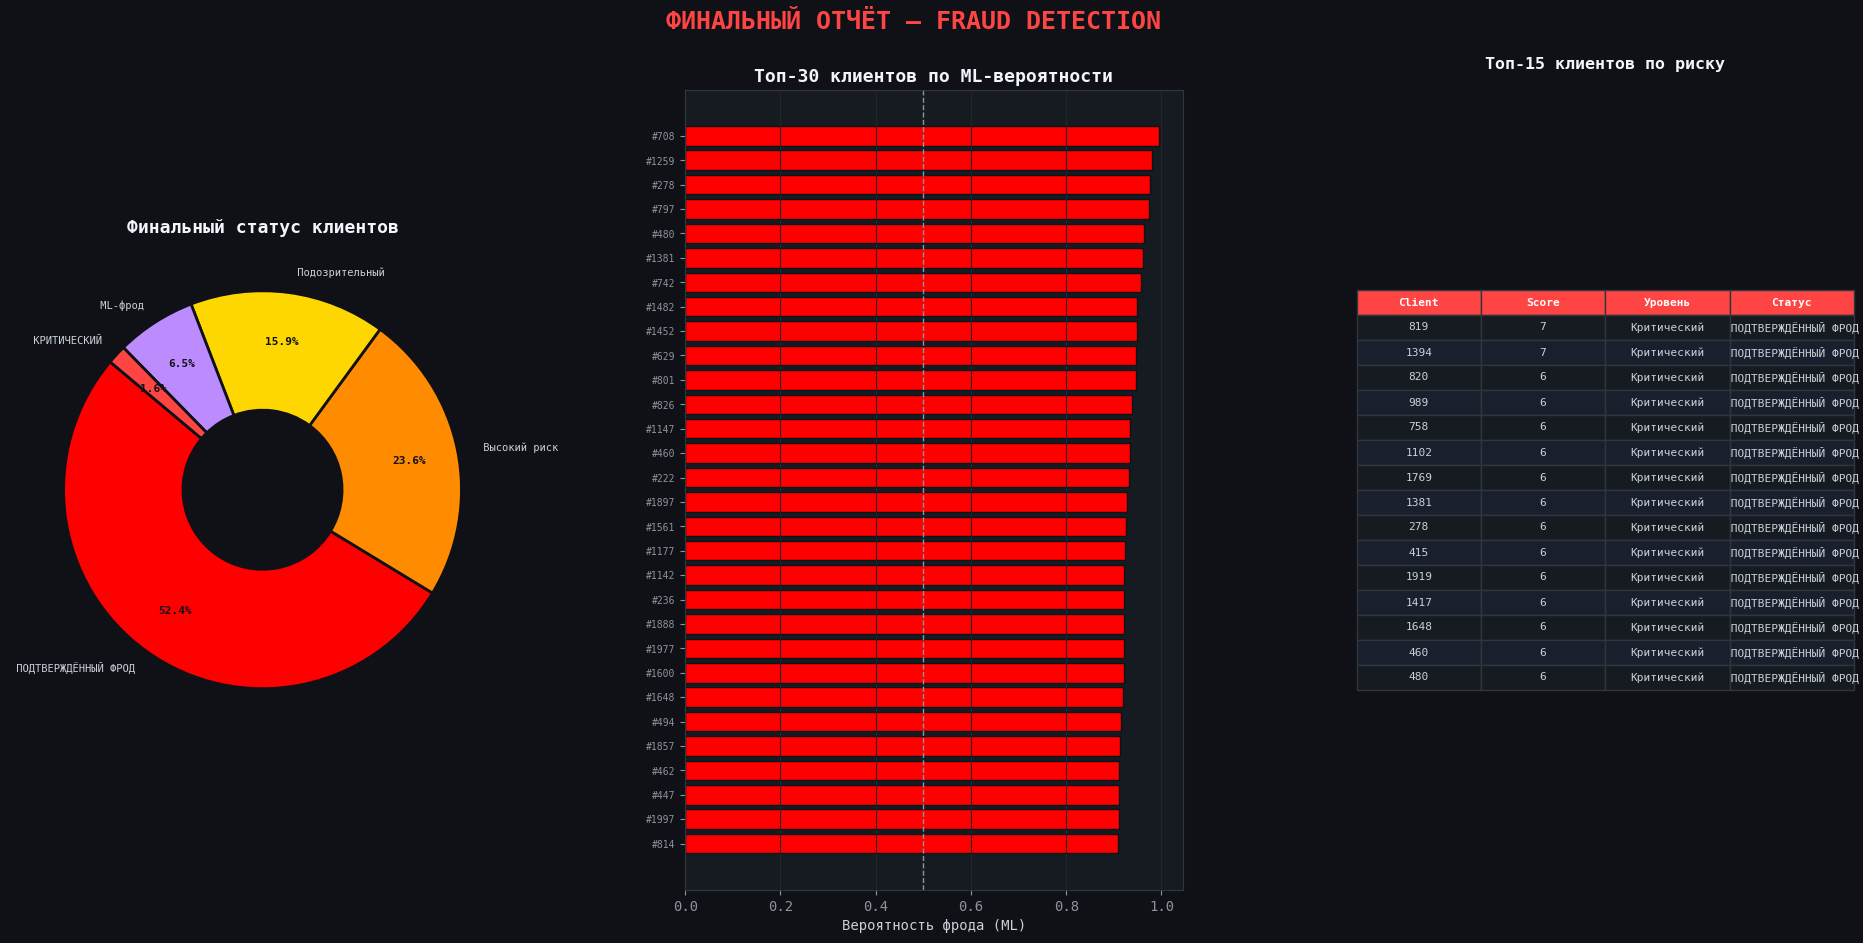


✅ Финальный отчёт сохранён: fraud_final_report.csv
   Подтверждённых фродеров: 639
   Требуют проверки:        386


In [19]:
# ════════════════════════════════════════════════════════════════
# 📊 БЛОК 12 — ВИЗУАЛИЗАЦИЯ ФИНАЛЬНОГО ОТЧЁТА
# ════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 10), facecolor=DARK_BG)
fig.suptitle('ФИНАЛЬНЫЙ ОТЧЁТ — FRAUD DETECTION',
             fontsize=18, fontweight='bold', color='#ff4444', y=0.98)
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35,
                       left=0.05, right=0.97, top=0.90, bottom=0.10)

# ── График 1: Финальный статус клиентов ──────────────────────
ax1 = fig.add_subplot(gs[0])
status_colors = {
    'Чистый':               '#3fb950',
    ' Подозрительный':    '#ffd700',
    ' Высокий риск':      '#ff8c00',
    ' ML-фрод':           '#bc8cff',
    ' КРИТИЧЕСКИЙ':       '#ff4444',
    ' ПОДТВЕРЖДЁННЫЙ ФРОД': '#ff0000',
}
sc = final['final_status'].value_counts()
colors_pie = [status_colors.get(s, '#58a6ff') for s in sc.index]
wedges, texts, autotexts = ax1.pie(
    sc.values, labels=sc.index, colors=colors_pie,
    autopct='%1.1f%%', startangle=140, pctdistance=0.75,
    wedgeprops=dict(width=0.6, edgecolor=DARK_BG, linewidth=2)
)
for at in autotexts: at.set_fontsize(8); at.set_color(DARK_BG); at.set_fontweight('bold')
for t in texts:      t.set_fontsize(7.5); t.set_color(TEXT_SUB)
ax1.set_title('Финальный статус клиентов')

# ── График 2: ML вероятность фрода (топ клиенты) ─────────────
ax2 = fig.add_subplot(gs[1])
top30 = final.nlargest(30, 'ml_fraud_proba')
bar_colors = [status_colors.get(s, '#58a6ff') for s in top30['final_status']]
ax2.barh(range(len(top30)), top30['ml_fraud_proba'],
         color=bar_colors, edgecolor=DARK_BG, height=0.8)
ax2.set_yticks(range(len(top30)))
ax2.set_yticklabels([f'#{cid}' for cid in top30['client_id']], fontsize=7)
ax2.set_xlabel('Вероятность фрода (ML)')
ax2.set_title('Топ-30 клиентов по ML-вероятности')
ax2.axvline(0.5, color=TEXT_MUTED, linestyle='--', linewidth=1)
ax2.grid(True, axis='x')
ax2.invert_yaxis()

# ── График 3: Таблица топ-15 фрод-клиентов ───────────────────
ax3 = fig.add_subplot(gs[2])
ax3.axis('off')
top15 = final.nlargest(15, 'risk_score')[[
    'client_id', 'risk_score', 'risk_level', 'final_status'
]].copy()
top15.columns = ['Client', 'Score', 'Уровень', 'Статус']

table = ax3.table(
    cellText=top15.values,
    colLabels=top15.columns,
    cellLoc='center', loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.5)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor(DARK_EDGE)
    if row == 0:
        cell.set_facecolor('#ff4444')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#1a1f2e')
        cell.set_text_props(color=TEXT_SUB)
    else:
        cell.set_facecolor(DARK_AX)
        cell.set_text_props(color=TEXT_SUB)

ax3.set_title('Топ-15 клиентов по риску', color=TEXT_MAIN,
              fontsize=12, fontweight='bold', pad=15)
plt.show()

# Сохраняем финальный датасет
final.to_csv(r'C:\Users\derbe\Downloads\fraud_final_report.csv', index=False)
print('\n✅ Финальный отчёт сохранён: fraud_final_report.csv')
print(f'   Подтверждённых фродеров: {(final["final_status"]==" ПОДТВЕРЖДЁННЫЙ ФРОД").sum()}')
print(f'   Требуют проверки:        {final["final_status"].isin([" Высокий риск", " КРИТИЧЕСКИЙ", " ML-фрод"]).sum()}')